In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install transformers==4.41.2 --no-deps
!pip install tokenizers==0.19.1 --no-deps  # Compatible version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.3 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 53.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2


In [2]:
# Data download and preprocessing for QQP (Quora Question Pairs)

from datasets import load_dataset
from transformers import AutoTokenizer
from pympler import asizeof
from torch.utils.data import DataLoader
from collections import Counter

# Load QQP dataset
qqp_dataset = load_dataset("glue", "qqp")

# Function to filter out invalid labels (if any)
def filter_valid(example):
    return example["label"] != -1

# Filter all QQP splits
qqp_dataset = {
    split: ds.filter(filter_valid) if "test" not in split else ds
    for split, ds in qqp_dataset.items()
}

# Create train dataset
train_dataset = qqp_dataset['train'].shuffle(seed=42)

# Split validation set into two equal halves
validation_full = qqp_dataset['validation'].shuffle(seed=42)
split_point = len(validation_full) // 2

validation_dataset = validation_full.select(range(split_point))
test_dataset = validation_full.select(range(split_point, len(validation_full)))

# Check the dataset structure
print(qqp_dataset)
print(f"\nExample from training set:")
print(qqp_dataset["train"][0])

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize function with dynamic padding for question pairs
def tokenize_function(example):
    return tokenizer(
        example["question1"],
        example["question2"],
        padding=False,  # No padding during tokenization
        truncation=True,
        max_length=128
    )

# Tokenize each dataset separately
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_validation = validation_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Change dataset format to use "labels" instead of "label"
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_validation = tokenized_validation.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

# Set format for PyTorch
tokenized_train.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_validation.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])

# Print dataset information
print(f"\nTrain dataset size: {len(tokenized_train)}")
print(f"Validation dataset size: {len(tokenized_validation)} (half of original dev set)")
print(f"Test dataset size: {len(tokenized_test)} (other half of original dev set)")

# Attention mask check
print(f"\nAttention mask example: {tokenized_train[0]['attention_mask']}")

# Check the train dataset dtype and size
size_in_bytes = asizeof.asizeof(tokenized_train)
size_in_mb = size_in_bytes / (1024 * 1024)
print(f"\nTotal size of tokenized_train: {size_in_mb:.2f} MB")

# Check label distribution - count of each label (0: not duplicate, 1: duplicate)

# Check label distribution
train_labels = [label.item() for label in tokenized_train["labels"]]
validation_labels = [label.item() for label in tokenized_validation["labels"]]

print(f"\nLabel distribution in train: {Counter(train_labels)}")
print(f"Label distribution in validation: {Counter(validation_labels)}")


# Check data types and shapes
print(f"\nData type and shape information:")
print(f"input_ids - shape: {tokenized_train[0]['input_ids'].shape}, dtype: {tokenized_train[0]['input_ids'].dtype}")
print(f"token_type_ids - shape: {tokenized_train[0]['token_type_ids'].shape}, dtype: {tokenized_train[0]['token_type_ids'].dtype}")
print(f"attention_mask - shape: {tokenized_train[0]['attention_mask'].shape}, dtype: {tokenized_train[0]['attention_mask'].dtype}")
print(f"labels - shape: {tokenized_train[0]['labels'].shape}, dtype: {tokenized_train[0]['labels'].dtype}")

# Check data types of each column
print("\nColumn data types:")
sample = tokenized_train[0]
for key, value in sample.items():
    print(f"Column: {key}, Data Type: {value.dtype}")

README.md: 0.00B [00:00, ?B/s]

qqp/train-00000-of-00001.parquet:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

qqp/validation-00000-of-00001.parquet:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

qqp/test-00000-of-00001.parquet:   0%|          | 0.00/36.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/363846 [00:00<?, ? examples/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/363846 [00:00<?, ? examples/s]

Map:   0%|          | 0/20215 [00:00<?, ? examples/s]

Map:   0%|          | 0/20215 [00:00<?, ? examples/s]


Train dataset size: 363846
Validation dataset size: 20215 (half of original dev set)
Test dataset size: 20215 (other half of original dev set)

Attention mask example: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1])

Total size of tokenized_train: 232.76 MB

Label distribution in train: Counter({0: 229468, 1: 134378})
Label distribution in validation: Counter({0: 12787, 1: 7428})

Data type and shape information:
input_ids - shape: torch.Size([29]), dtype: torch.int64
token_type_ids - shape: torch.Size([29]), dtype: torch.int64
attention_mask - shape: torch.Size([29]), dtype: torch.int64
labels - shape: torch.Size([]), dtype: torch.int64

Column data types:
Column: labels, Data Type: torch.int64
Column: input_ids, Data Type: torch.int64
Column: token_type_ids, Data Type: torch.int64
Column: attention_mask, Data Type: torch.int64


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time
import wandb
import random
import os
import inspect
from tqdm import tqdm
from contextlib import nullcontext
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint



# ------------------------------------dynamic tanh---------------------------------------------------
class DyT(nn.Module):
    def __init__(self, num_features, alpha_init_value=0.5):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(1) * alpha_init_value)
        self.weight = nn.Parameter(torch.ones(num_features))
        self.bias = nn.Parameter(torch.zeros(num_features))
    
    def forward(self, x):
        x = torch.tanh(self.alpha * x)
        return x * self.weight + self.bias

# ------------------------------------MHA---------------------------------------------------

class Attention(nn.Module):
    """Multi-head attention"""
    def __init__(self, config):
        super().__init__()
        assert config.n_embed % config.n_head == 0, "Embedding dim must be divisible by num heads"

        self.n_head = config.n_head
        self.n_embed = config.n_embed
        self.head_dim = config.n_embed // config.n_head

        self.qkv_proj = nn.Linear(config.n_embed, 3 * config.n_embed)
        self.output_proj = nn.Linear(config.n_embed, config.n_embed)
        self.dropout = nn.Dropout(config.dropout)



    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None) -> torch.Tensor:
        B, T, C = x.shape

        # Project to queries, keys, values
        qkv = self.qkv_proj(x)
        q, k, v = qkv.split(self.n_embed, dim=2)

        # Reshape for multi-head attention
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hs)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hs)


        # Process attention mask
        attn_mask = None
        if attention_mask is not None:
            # Expand from (B, T) to (B, 1, 1, T) for broadcasting
            attn_mask = attention_mask.unsqueeze(1).unsqueeze(2)

        # Compute attention
        y = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=attn_mask,
            is_causal=False
        )

        # Reshape and project
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.dropout(self.output_proj(y))

        return y

# -----------------------------------Expert--------------------------------------------------

class Expert(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embed,2*config.n_embed),
            nn.GELU(),
            nn.Linear(2*config.n_embed,config.n_embed),
            nn.Dropout(config.dropout)
        )

    def forward(self,x):
        return self.net(x)

# ------------------------------------MLP--------------------------------------------------

class MLP(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embed,4*config.n_embed),
            nn.GELU(),
            nn.Linear(4*config.n_embed,config.n_embed),
            nn.Dropout(config.dropout)
        )

    def forward(self,x):
        return self.net(x)

# ------------------------------------NoisyTopkRouter--------------------------------------------------

class NoisyTopkRouter(nn.Module):
    def __init__(self, config):
        super(NoisyTopkRouter, self).__init__()
        self.top_k = config.top_k
        # Layer for router logits
        self.topkroute_linear = nn.Linear(config.n_embed, config.num_experts)
        self.noise_linear = nn.Linear(config.n_embed, config.num_experts)
    
    def forward(self, mh_output):
        # mh_ouput is the output tensor from multihead self attention block
        logits = self.topkroute_linear(mh_output)
        # Noise logits
        noise_logits = self.noise_linear(mh_output)
        # Adding scaled unit gaussian noise to the logits
        noise = torch.randn_like(logits) * F.softplus(noise_logits)
        noisy_logits = logits + noise
        top_k_logits, indices = noisy_logits.topk(self.top_k, dim=-1)
        zeros = torch.full_like(noisy_logits, float('-inf'))
        sparse_logits = zeros.scatter(-1, indices, top_k_logits)
        router_output = F.softmax(sparse_logits, dim=-1)
        return router_output, indices, logits


# ------------------------------------SparseMoE--------------------------------------------------

class SparseMoE(nn.Module):
    def __init__(self, config):
        super(SparseMoE, self).__init__()
        self.router = NoisyTopkRouter(config)
        self.experts = nn.ModuleList([Expert(config) for _ in range(config.num_experts)])
        self.top_k = config.top_k
        self.capacity_factor = config.capacity_factor
        self.num_experts = config.num_experts
        
        # Load balancing parameters
        self.use_load_balancing = getattr(config, "use_load_balancing", True)
        self.load_balance_weight = getattr(config, "load_balance_weight", 0.01)
        self.aux_loss = 0.0
    
    def _compute_load_balancing_loss(self, router_logits, expert_indices):
        """
        Computes auxiliary load balancing loss to encourage uniform expert utilization
        
        Args:
            router_logits: Original router logits before noise [batch_size, seq_len, num_experts]
            expert_indices: Expert assignments [batch_size, seq_len, top_k]
        """
        # Calculate fraction of tokens assigned to each expert
        batch_size, seq_len, _ = router_logits.shape
        
        # More efficient one-hot representation of expert assignment
        # Shape: [batch_size, seq_len, top_k, num_experts]
        one_hot = F.one_hot(expert_indices, num_classes=self.num_experts)
        # Sum across top-k dimension to get mask of shape [batch_size, seq_len, num_experts]
        mask = one_hot.sum(dim=2).float()
        
        # Calculate the fraction of tokens routed to each expert
        routing_probs = mask.mean(dim=[0, 1])  # Shape [num_experts]
        
        # Calculate router probabilities from logits
        router_probs = F.softmax(router_logits, dim=-1)  # [batch_size, seq_len, num_experts]
        
        # Calculate mean probability assigned to each expert
        router_probs = router_probs.mean(dim=[0, 1])  # Shape [num_experts]
        
        # Loss is the dot product between router probability and expert assignment fraction
        # This encourages the router to distribute tokens uniformly
        loss = routing_probs @ router_probs * self.num_experts
        
        return loss
    
    def forward(self, x):
        """
        Forward pass with load balancing
        
        Args:
            x: Input tensor of shape [batch_size, seq_len, n_embed]
        """
        batch_size, seq_len, embed_dim = x.shape
        total_tokens = batch_size * seq_len
        
        # Get routing probabilities and expert assignments
        router_probs, indices, router_logits = self.router(x)
        
        if self.training and self.use_load_balancing:
            self.aux_loss = self._compute_load_balancing_loss(router_logits, indices)
        else:
            self.aux_loss = 0.0
        
        # Reshape input for expert processing
        # [batch_size, seq_len, embed_dim] -> [batch_size * seq_len, embed_dim]
        flat_x = x.reshape(-1, embed_dim)
        
        # Calculate expert capacity - how many tokens each expert should process
        # We use capacity_factor > 1.0 to allow for some imbalance
        tokens_per_expert = int((total_tokens * self.top_k / self.num_experts) * self.capacity_factor)
        
        # Initialize output tensor
        combined_output = torch.zeros_like(flat_x)
        
        # Create a mask for combining outputs, shape [batch_size * seq_len, num_experts]
        combine_weights = router_probs.view(-1, self.num_experts)
        
        # Process each expert
        for expert_idx, expert in enumerate(self.experts):
            # Find which tokens go to this expert
            # Shape: [batch_size, seq_len]
            expert_mask = (indices == expert_idx).any(dim=-1)
            # Flatten to [batch_size * seq_len]
            flat_mask = expert_mask.reshape(-1)
            # Get indices of tokens assigned to this expert
            token_indices = flat_mask.nonzero(as_tuple=True)[0]
            
            # Only process if we have tokens for this expert
            if token_indices.numel() > 0:
                # Apply capacity constraints if needed
                if token_indices.numel() > tokens_per_expert:
                    # Too many tokens assigned, need to drop some
                    # Get the routing probabilities for this expert
                    expert_probs = combine_weights[token_indices, expert_idx]
                    # Sort by probability
                    sorted_indices = torch.argsort(expert_probs, descending=True)
                    # Keep only tokens within capacity
                    selected_indices = sorted_indices[:tokens_per_expert]
                    
                    # Get the actual indices in the flattened input
                    token_indices = token_indices[selected_indices]
                
                # Process expert computation for selected tokens
                expert_inputs = flat_x[token_indices]
                expert_outputs = expert(expert_inputs)
                expert_weights = combine_weights[token_indices, expert_idx].unsqueeze(-1)
                weighted_outputs = expert_outputs * expert_weights
                combined_output.index_add_(0, token_indices, weighted_outputs)
        
        # Reshape back to original dimensions
        output = combined_output.reshape(batch_size, seq_len, embed_dim)
        
        return output
    
    def get_load_balancing_loss(self):
        """Return the load balancing auxiliary loss"""
        return self.aux_loss * self.load_balance_weight if self.use_load_balancing else 0.0


# ------------------------------------Block---------------------------------------------------

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.use_moe = config.use_moe
        self.ln1 = DyT(config.n_embed)
        self.attn = Attention(config)
        self.ln2 = DyT(config.n_embed)
        if self.use_moe:
            self.moe = SparseMoE(config)
        else:
            self.moe = MLP(config)

    def forward(self, x, attention_mask=None):
        x = x + self.attn(self.ln1(x), attention_mask)
        x = x + self.moe(self.ln2(x))
        return x


#-----------------------------BERT Embedding---------------------------------------------------------

class BERTEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embed = nn.Embedding(config.vocab_size, config.n_embed)
        self.position_embed = nn.Embedding(config.block_size, config.n_embed)
        self.segment_embed = nn.Embedding(2, config.n_embed)  # Only 2 segment types for BERT
        self.ln = nn.LayerNorm(config.n_embed)
        self.dropout = nn.Dropout(config.dropout)
        
    def forward(self, input_ids, segment_ids):
        # Debug: Print shapes to understand the issue
        # print(f"Debug - input_ids shape: {input_ids.shape}")
        # print(f"Debug - segment_ids shape: {segment_ids.shape}")
        
        # seq_len = input_ids.size(1) #B,T
        batch_size, seq_len = input_ids.shape
        pos_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device).unsqueeze(0)
        
        token_emb = self.token_embed(input_ids)
        pos_emb = self.position_embed(pos_ids)
        seg_emb = self.segment_embed(segment_ids)
        
        embeddings = token_emb + seg_emb + pos_emb
        return self.dropout(self.ln(embeddings))


class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
    
        self.use_moe=config.use_moe
        
        self.embedding = BERTEmbedding(config)
        # Cannot use nn.Sequential when we need to pass additional parameters like attention_mask
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln = nn.RMSNorm(config.n_embed)
        self.head = nn.Linear(config.n_embed, config.num_labels)

        # Collect all MoE layers from blocks
        if self.use_moe:
            self.moe_layers = nn.ModuleList([block.moe for block in self.blocks])
        
        # Apply weight initialization
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

            
    def forward(self, input_ids, segment_ids, targets=None, attention_mask=None):
        x = self.embedding(input_ids, segment_ids)
        
        # Process through each block manually to pass attention_mask
        for block in self.blocks:
            x = block(x, attention_mask)
            
        x = self.ln(x[:, 0, :])  # Take [CLS] token representation for classification
        logits = self.head(x)
        
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits, targets)

            if self.use_moe:
                # Add auxiliary load balancing loss from all MoE layers
                aux_loss = 0.0
                for moe_layer in self.moe_layers:
                    aux_loss += moe_layer.get_load_balancing_loss()
                
                # Combine losses
                loss = loss + aux_loss
        
        return logits, loss
        
        
    def configure_optimizers(self, weight_decay, learning_rate, device, verbose=False):

        # Step 1: Collect trainable parameters (excluding frozen ones)
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
    
        # Step 2: Separate weight decay (2D+ tensors) and no decay (biases, LayerNorm)
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]  # Weight matrices
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]  # Biases, LayerNorm
    
        # Step 3: Define optimizer parameter groups
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},  # Apply weight decay
            {'params': nodecay_params, 'weight_decay': 0.0}  # No weight decay
        ]

        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and 'cuda' in device
        
        # Debugging - Print parameter stats (optional)
        if verbose:
            num_decay_params = sum(p.numel() for p in decay_params)
            num_nodecay_params = sum(p.numel() for p in nodecay_params)
            print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params/1e6}M parameters")
            print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params/1e6}M parameters")
            print(f"Using fused AdamW: {use_fused}")

        # Create AdamW optimizer
        optimizer = torch.optim.AdamW(
            optim_groups, 
            lr=learning_rate, 
            betas = (0.9, 0.999),  # Momentum values,  # Momentum values
            eps=1e-8,  # Small epsilon for numerical stability
            fused=use_fused  # Enable fused version if available
        )
    
        return optimizer



@dataclass
class BERTConfig:
    block_size:int = 128
    # batch_size:int = 32 
    vocab_size:int = 30522
    n_layer:int = 8 #8 12 16
    n_head:int = 4 #8,12,16
    n_embed:int = 256 # 256 512 576 768,1024
    dropout:float = 0.1
    num_labels:int = 2
    use_full_precision:bool=False
    # mixture of experts
    use_moe:bool=True
    top_k:int = 2
    capacity_factor:float = 1.15
    num_experts:int = 6
    use_load_balancing: bool = True
    load_balance_weight: float = 0.01
    
    device:str = "cuda" if torch.cuda.is_available() else "cpu"

device = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(1337)
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)


# config = BERTConfig()
model = BERT(BERTConfig())

model = model.to(device)

# model = torch.compile(model)
# model=torch.jit.script(model)

total_params = sum(param.numel() for param in model.parameters())
print(f"Total number of parameters: {total_params/1e6}M")


#TF16
torch.set_float32_matmul_precision('high')

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Total number of parameters: 22.606194M


In [ ]:
# del model,optimizer

In [10]:
import os
import math
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
from torch.cuda.amp import GradScaler, autocast
from datetime import datetime, timezone

batch_size = 256

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

train_dataloader = DataLoader(
    tokenized_train,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)
val_dataloader = DataLoader(
    tokenized_validation,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

# Quick check
print(f"Training batches: {len(train_dataloader)}") 
print(f"Validation (matched) batches: {len(val_dataloader)}")


#---------------------------------------Training hyperparameters---------------------------------
num_epochs = 4
max_steps = num_epochs * len(train_dataloader)   #29440-32, 14720-64
grad_clip = 1.0  # Gradient clipping value
eval_interval = 500  # 262,525
log_interval = 100  # Log loss every 100 steps

# Setup learning rate scheduler
max_lr = 5.5e-4
min_lr = 5.5e-5

warmup_steps = int(0.05 * max_steps)  
plateau = int(0.3 * max_steps)

device = "cuda" if torch.cuda.is_available() else "cpu"



# ---------------------------------cosine learning rate scheduler with warmup------------------------------------------------

def get_lr(it):
    # Linear warm-up
    if it < warmup_steps:
        return max_lr * (it + 1) / warmup_steps
    if it<plateau:
        return max_lr
    # If it > max_steps return min lr
    if it > max_steps:
        return min_lr
    # Cosine decay between warmup and max steps
    decay_ratio = (it - plateau) / (max_steps - plateau)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)


optimizer = model.configure_optimizers(weight_decay=0.1,learning_rate=max_lr,device=device,verbose=True)


# ---------------------------------------------------------------------------------------------------------

# History tracking for plots
train_losses = []
val_losses = []
val_accs = []
steps_history = []


def evaluate(dataloader, split_name):
    """Evaluation function with cleaner progress display"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # Create a progress bar that updates in place
    progress_bar = tqdm(dataloader, desc=f"Evaluating {split_name}",
                        leave=True, position=0,
                        ncols=80,  # Adjust width as needed
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

    with torch.no_grad():
        for batch in progress_bar:
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()

            # Forward pass
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)

            # Get predictions
            preds = torch.argmax(logits, dim=-1)

            # Track predictions and labels
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()

            # Update progress bar with current accuracy
            current_acc = (preds == labels).sum().item() / labels.size(0)
            progress_bar.set_postfix(batch_acc=f"{current_acc:.4f}",
                                    loss=f"{loss.item():.4f}",
                                    refresh=False)

    # Calculate metrics
    accuracy = correct / total
    avg_loss = total_loss / len(dataloader)

    # Print final metrics
    print(f"\n{split_name} Results | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

    return {
        "loss": avg_loss,
        "accuracy": accuracy
    }

def plot_training_history():
    """Plot training and validation metrics."""
    plt.figure(figsize=(12, 8))

    # Plot losses
    plt.subplot(2, 1, 1)
    plt.plot(steps_history, train_losses, label='Train Loss')
    plt.plot(steps_history, val_losses, label='Val Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot accuracies
    plt.subplot(2, 1, 2)
    plt.plot(steps_history, val_accs, label='Val Accuracy')
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()
    print("Training history plot saved to 'training_history.png'")

# Main training function
def train():
    global_step = 0
    best_val_acc = 0.0
    start_time = time.time()  # Start timer


    # Initialize history tracking
    global train_losses, val_losses 
    global val_accs, steps_history

    # Main training loop
    for epoch in range(num_epochs):
        print(f"Starting epoch {epoch+1}/{num_epochs}")
        model.train()

        # Track metrics for this epoch
        epoch_losses = []

        # Use standard PyTorch dataloader iteration
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")
        for batch in progress_bar:
            if global_step >= max_steps:
                break

            t0 = time.time()

            # Get batch data and move to device
            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()


            # Zero gradients
            optimizer.zero_grad()

            # # Forward pass
            # logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)

            #-------------------------------------autocast---------------------------------
            with torch.autocast(device_type=device,dtype=torch.bfloat16):
                    logits,loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)

            #------------------------------------------------------------------------------

            # Backward pass
            loss.backward()

            # Gradient clipping
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            # Update learning rate
            lr = get_lr(global_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            # Update weights
            optimizer.step()

            # Track epoch loss
            current_loss = loss.item()
            epoch_losses.append(current_loss)

            # Synchronize CUDA for accurate timing
            if torch.cuda.is_available():
                torch.cuda.synchronize()

            # Calculate speed metrics
            t1 = time.time()
            dt = (t1 - t0)

            # Tokens processed calculation
            batch_size = input_ids.size(0)
            sequence_length = input_ids.size(1)
            tokens_processed = batch_size * sequence_length
            tokens_per_sec = tokens_processed / dt

            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'lr': f'{lr:.2e}',
                'tok/s': f'{tokens_per_sec:.0f}'
            })

            # Log training metrics
            if global_step % log_interval == 0:
                print(f'step {global_step:6d} | loss: {current_loss:.6f} | lr: {lr:.4e} | '
                      f'dt: {dt*1000:.2f}ms | norm: {norm:.4f} | tok/sec: {tokens_per_sec:.2f}')

            # Evaluation
            if global_step > 0 and global_step % eval_interval == 0:
                print(f"\nEvaluating at step {global_step}...")
                val_metrics = evaluate(val_dataloader, "val")

                # Calculate average validation accuracy + val_mismatched_metrics["accuracy"]) / 2
                val_acc = val_metrics["accuracy"] 

                # Track metrics for plotting
                avg_train_loss = sum(epoch_losses[-100:]) / min(len(epoch_losses), 100)  # Average of last 100 steps
                train_losses.append(avg_train_loss)
                val_losses.append(val_metrics["loss"])
                val_accs.append(val_metrics["accuracy"])
                steps_history.append(global_step)

                # Save best model
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    torch.save(model.state_dict(), "best_model.pt")
                    print(f"New best validation accuracy: {best_val_acc:.4f}")

                # Generate and save plots
                plot_training_history()

                # Back to training mode
                model.train()
                print("")  # Add empty line for readability

            # Increment global step
            global_step += 1

        # End of epoch
        epoch_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"\nEpoch {epoch+1} completed | Average loss: {epoch_loss:.6f}")

    # Save final model
    torch.save(model.state_dict(), "final_model.pt")
    end_time = time.time()  # End timer
    elapsed = end_time - start_time

    # Save training time
    elapsed_str = datetime.fromtimestamp(elapsed, tz=timezone.utc).strftime("%H:%M:%S")
    print(f"\nTraining completed in {elapsed:.2f} seconds ({elapsed_str})")
    print("Training completed. Final model saved to 'final_model.pt'")
    print(f"Best validation accuracy: {best_val_acc:.4f}")

Training batches: 1422
Validation (matched) batches: 79
num decayed parameter tensors: 132, with 22.552064M parameters
num non-decayed parameter tensors: 180, with 0.05413M parameters
Using fused AdamW: True


In [11]:
train()

Starting epoch 1/4


Epoch 1:   0%|          | 1/1422 [00:00<15:08,  1.56it/s, loss=0.4970, lr=1.94e-06, tok/s=51780]

step      0 | loss: 0.497013 | lr: 1.9366e-06 | dt: 568.56ms | norm: 1.0059 | tok/sec: 51779.64


Epoch 1:   7%|▋         | 101/1422 [00:51<11:13,  1.96it/s, loss=0.4205, lr=1.96e-04, tok/s=53055]

step    100 | loss: 0.420535 | lr: 1.9560e-04 | dt: 559.72ms | norm: 0.8068 | tok/sec: 53054.87


...

Training history plot saved to 'training_history.png'



Epoch 4:  94%|█████████▍| 1335/1422 [12:09<00:44,  1.97it/s, loss=0.3504, lr=5.56e-05, tok/s=51053]

step   5600 | loss: 0.350434 | lr: 5.5596e-05 | dt: 406.17ms | norm: 2.5078 | tok/sec: 51052.56


Epoch 4: 100%|██████████| 1422/1422 [12:52<00:00,  1.84it/s, loss=0.3743, lr=5.50e-05, tok/s=39253]



Epoch 4 completed | Average loss: 0.318254

Training completed in 3080.54 seconds (00:51:20)
Training completed. Final model saved to 'final_model.pt'
Best validation accuracy: 0.8393


In [12]:
# this is for test set

batch_size = 256

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)


test_dataloader = DataLoader(
    tokenized_test,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)


print(f"Test SST2 size: {len(tokenized_test)}")

Test SST2 size: 20215


Loading best model...
Model loaded successfully!

Starting final evaluation on test set...


Evaluating Test Set:   0%|          | 0/79 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2717: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



                Test Set EVALUATION RESULTS                 
Loss: 0.5171
Accuracy: 0.8341 (16861/20215)
F1 Score (Positive): 0.7865
F1 Score (Macro): 0.8254
F1 Score (Weighted): 0.8356

               CONFUSION MATRIX VISUALIZATION               


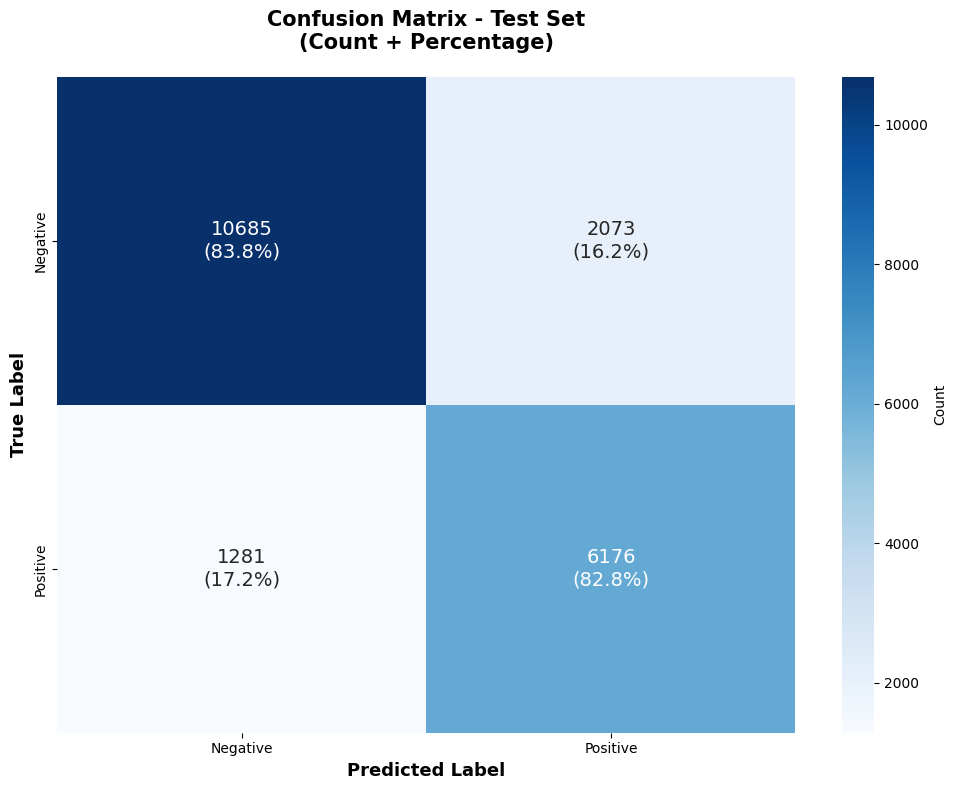

Confusion matrix saved to: confusion_matrix_test_set_20260105_103515.png

                   CLASSIFICATION REPORT                    
              precision    recall  f1-score   support

    Negative     0.8929    0.8375    0.8643     12758
    Positive     0.7487    0.8282    0.7865      7457

    accuracy                         0.8341     20215
   macro avg     0.8208    0.8329    0.8254     20215
weighted avg     0.8397    0.8341    0.8356     20215

                 PER-CLASS DETAILED METRICS                 

Negative:
  Accuracy:  0.8375 (10685/12758)
  Precision: 0.8929
  Recall:    0.8375
  F1 Score:  0.8643

Positive:
  Accuracy:  0.8282 (6176/7457)
  Precision: 0.7487
  Recall:    0.8282
  F1 Score:  0.7865



                   FINAL TEST SET SUMMARY                   
Loss:              0.5171
Accuracy:          0.8341
F1 (Positive):     0.7865
F1 (Macro):        0.8254
F1 (Weighted):     0.8356

Per-Class Metrics:
  Negative: Acc=0.8375, P=0.8929, R=0.8375, F1=0.8643
 

In [13]:
# Final evaluation on test set for SST-2

import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score, classification_report, precision_recall_fscore_support


def final_evaluation(model, dataloader, split_name, class_names=None, device=None):
    """
    Comprehensive evaluation function for final reporting on SST-2 dataset.
    
    Args:
        model: PyTorch model in evaluation mode.
        dataloader: PyTorch DataLoader with input_ids, token_type_ids, labels, attention_mask.
        split_name (str): Name of the dataset split (e.g., "Test", "Validation").
        class_names (list): List of class names (e.g., ["Negative", "Positive"]). 
                           Defaults to None, using numeric labels if not provided.
        device: Torch device (e.g., torch.device("cuda")). If None, uses model's device.
    
    Returns:
        dict: Metrics including loss, accuracy, F1 scores, confusion matrix, and per-class metrics.
    """
    if device is None:
        device = next(model.parameters()).device
    
    if class_names is None:
        class_names = ["Negative", "Positive"]  # Default for binary classification
    
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    num_examples = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {split_name}", leave=False):
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()
            
            # Forward pass with autocast
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)
            
            # Compute predictions
            preds = torch.argmax(logits, dim=-1)
            
            # Track predictions and labels
            batch_size = input_ids.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            total_loss += loss.item() * batch_size
            num_examples += batch_size
    
    # Convert to numpy arrays for sklearn
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate basic metrics
    correct = np.sum(y_true == y_pred)
    accuracy = correct / len(y_true)
    avg_loss = total_loss / num_examples  # Weighted average by batch size
    
    # Calculate F1 scores
    f1_binary = f1_score(y_true, y_pred, average='binary')  # For positive class
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    # Calculate precision, recall, F1 per class
    precision, recall, f1_per_class, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1]
    )
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class metrics
    per_class_metrics = {}
    for cls_idx, cls_name in enumerate(class_names):
        cls_indices = np.where(y_true == cls_idx)[0]
        cls_correct = np.sum(y_pred[cls_indices] == y_true[cls_indices])
        cls_acc = cls_correct / len(cls_indices) if len(cls_indices) > 0 else 0
        per_class_metrics[cls_name] = {
            "accuracy": cls_acc,
            "precision": precision[cls_idx],
            "recall": recall[cls_idx],
            "f1": f1_per_class[cls_idx],
            "correct": int(cls_correct),
            "total": len(cls_indices)
        }
    
    # Print metrics
    print(f"\n{'='*60}")
    print(f"{split_name} EVALUATION RESULTS".center(60))
    print(f"{'='*60}")
    print(f"Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f} ({correct}/{len(y_true)})")
    print(f"F1 Score (Positive): {f1_binary:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")
    
    # Enhanced confusion matrix visualization
    print(f"\n{'='*60}")
    print("CONFUSION MATRIX VISUALIZATION".center(60))
    print(f"{'='*60}")
    
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    plt.figure(figsize=(10, 8))
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create custom annotations with count + percentage
    annotations = []
    for i in range(cm.shape[0]):
        row = []
        for j in range(cm.shape[1]):
            row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
        annotations.append(row)
    
    sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 14})
    plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
    plt.ylabel('True Label', fontsize=13, fontweight='bold')
    plt.title(f'Confusion Matrix - {split_name}\n(Count + Percentage)', 
              fontsize=15, fontweight='bold', pad=20)
    plt.tight_layout()
    
    plot_filename = f'confusion_matrix_{split_name.lower().replace(" ", "_")}_{timestamp}.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Confusion matrix saved to: {plot_filename}")
    
    # Print classification report
    print(f"\n{'='*60}")
    print("CLASSIFICATION REPORT".center(60))
    print(f"{'='*60}")
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(report)
    
    # Print per-class detailed metrics
    print(f"{'='*60}")
    print("PER-CLASS DETAILED METRICS".center(60))
    print(f"{'='*60}")
    for cls_name, stats in per_class_metrics.items():
        print(f"\n{cls_name}:")
        print(f"  Accuracy:  {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")
        print(f"  Precision: {stats['precision']:.4f}")
        print(f"  Recall:    {stats['recall']:.4f}")
        print(f"  F1 Score:  {stats['f1']:.4f}")
    
    print(f"\n{'='*60}\n")
    
    # Return comprehensive metrics
    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "f1_binary": f1_binary,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm.tolist(),
        "per_class_metrics": per_class_metrics
    }


# Load the saved model weights
print("Loading best model...")
model = BERT(BERTConfig())  # Initialize model with the same config
model.load_state_dict(torch.load("best_model.pt"))  # Load the best weights
model = model.to(device)  # Move model to the appropriate device
model.eval()  # Set model to evaluation mode
print("Model loaded successfully!\n")

# Define class names for SST-2 (binary sentiment classification)
class_names = ["Negative", "Positive"]
# "Negative"->"Not Duplicate", "Positive"->"Duplicate"

# Run final evaluation on test set
print("Starting final evaluation on test set...")
test_metrics = final_evaluation(
    model=model,
    dataloader=test_dataloader,
    split_name="Test Set",
    class_names=class_names,
    device=device
)

# Print summary of key metrics
print("\n" + "="*60)
print("FINAL TEST SET SUMMARY".center(60))
print("="*60)
print(f"Loss:              {test_metrics['loss']:.4f}")
print(f"Accuracy:          {test_metrics['accuracy']:.4f}")
print(f"F1 (Positive):     {test_metrics['f1_binary']:.4f}")
print(f"F1 (Macro):        {test_metrics['f1_macro']:.4f}")
print(f"F1 (Weighted):     {test_metrics['f1_weighted']:.4f}")
print("\nPer-Class Metrics:")
for cls_name, stats in test_metrics['per_class_metrics'].items():
    print(f"  {cls_name}: Acc={stats['accuracy']:.4f}, "
          f"P={stats['precision']:.4f}, R={stats['recall']:.4f}, F1={stats['f1']:.4f}")
print("="*60)

Starting final evaluation on val set...


Evaluating Val Set:   0%|          | 0/79 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2717: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



                 Val Set EVALUATION RESULTS                 
Loss: 0.4994
Accuracy: 0.8393 (16966/20215)
F1 Score (Positive): 0.7930
F1 Score (Macro): 0.8308
F1 Score (Weighted): 0.8408

               CONFUSION MATRIX VISUALIZATION               


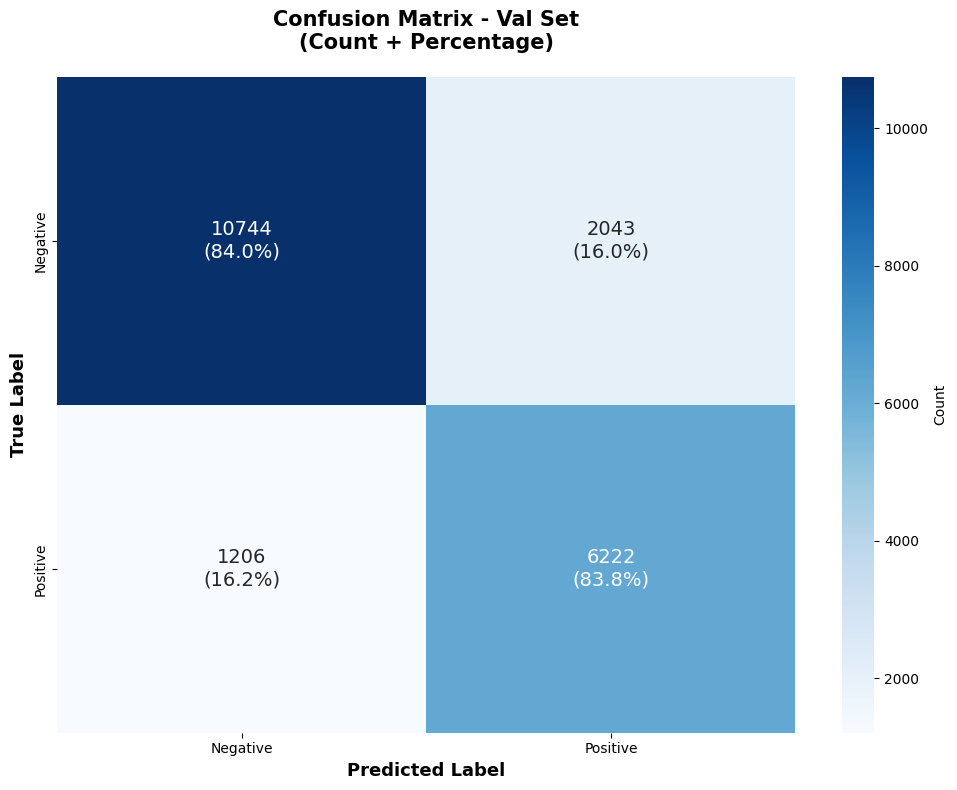

Confusion matrix saved to: confusion_matrix_val_set_20260105_103752.png

                   CLASSIFICATION REPORT                    
              precision    recall  f1-score   support

    Negative     0.8991    0.8402    0.8687     12787
    Positive     0.7528    0.8376    0.7930      7428

    accuracy                         0.8393     20215
   macro avg     0.8259    0.8389    0.8308     20215
weighted avg     0.8453    0.8393    0.8408     20215

                 PER-CLASS DETAILED METRICS                 

Negative:
  Accuracy:  0.8402 (10744/12787)
  Precision: 0.8991
  Recall:    0.8402
  F1 Score:  0.8687

Positive:
  Accuracy:  0.8376 (6222/7428)
  Precision: 0.7528
  Recall:    0.8376
  F1 Score:  0.7930



                   FINAL Val SET SUMMARY                    
Loss:              0.4994
F1 (Positive):     0.7930
F1 (Macro):        0.8308
F1 (Weighted):     0.8408

Per-Class Metrics:
  Negative: Acc=0.8402, P=0.8991, R=0.8402, F1=0.8687
  Positive: Acc=0.8376, P=0.

In [14]:
# Run final evaluation on val set
print("Starting final evaluation on val set...")
test_metrics = final_evaluation(
    model=model,
    dataloader=val_dataloader,
    split_name="Val Set",
    class_names=class_names,
    device=device
)

# Print summary of key metrics
print("\n" + "="*60)
print("FINAL Val SET SUMMARY".center(60))
print("="*60)
print(f"Loss:              {test_metrics['loss']:.4f}")
print(f"F1 (Positive):     {test_metrics['f1_binary']:.4f}")
print(f"F1 (Macro):        {test_metrics['f1_macro']:.4f}")
print(f"F1 (Weighted):     {test_metrics['f1_weighted']:.4f}")
print("\nPer-Class Metrics:")
for cls_name, stats in test_metrics['per_class_metrics'].items():
    print(f"  {cls_name}: Acc={stats['accuracy']:.4f}, "
          f"P={stats['precision']:.4f}, R={stats['recall']:.4f}, F1={stats['f1']:.4f}")
print("="*60)

In [15]:
print("har har mahadev")

har har mahadev


best_model.pt				       final_model.pt
confusion_matrix_test_set_20260105_103515.png  training_history.png
confusion_matrix_val_set_20260105_103752.png


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


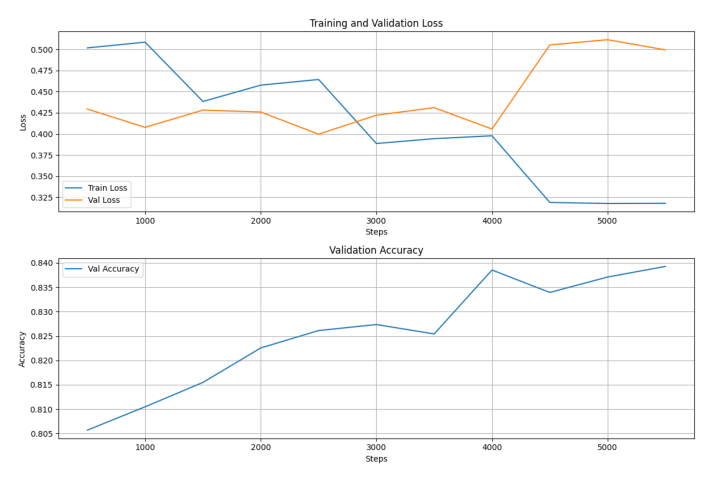

In [16]:
!ls
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('training_history.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()
